In [198]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [199]:
import json

from protest_impact.util import project_root

with open(project_root / "data" / "protest" / "predictions.jsonl") as f:
    predictions = [json.loads(line) for line in f]

with open(project_root / "data" / "news" / "protest_news_shuffled_v2.jsonl") as f:
    news = [json.loads(line) for line in f]

In [200]:
protest_news = []
for prediction, article in zip(predictions, news):
    if prediction["label"] == "LABEL_1":
        for k, v in article["meta"].items():
            article[k] = v
        del article["meta"]
        article["score"] = prediction["score"]
        protest_news.append(article)

In [201]:
len(protest_news)

20879

In [202]:
protest_news.sort(key=lambda x: x["score"], reverse=True)

In [203]:
%%capture
protest_news[:5]

In [204]:
%%capture
protest_news[-5:]

In [205]:
%%capture
protest_news[-505:-500]

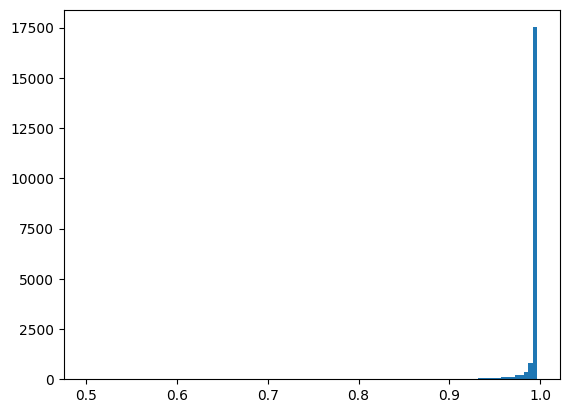

In [206]:
# plot distribution of scores
import matplotlib.pyplot as plt
import numpy as np

scores = [article["score"] for article in protest_news]
plt.hist(scores, bins=100)
plt.show()

In [207]:
with open(project_root / "data" / "protest" / "protest_news_predicted.jsonl", "w") as f:
    for article in protest_news:
        f.write(json.dumps(article) + "\n")

In [208]:
from protest_impact.data.protests.config import movement_keywords

topics = {}
for movement, keywords in movement_keywords.items():
    topics[movement] = []
    if "movement" in keywords:
        topics[movement] += keywords["movement"]
    if "topic" in keywords:
        topics[movement] += keywords["topic"]
    topics[movement] = [a.replace("*", "") for a in topics[movement]]

In [209]:
for article in protest_news:
    article["topics"] = []
    text = article["text"].lower()
    for movement, keywords in topics.items():
        for keyword in keywords:
            if keyword in text:
                article["topics"].append(movement)
                break

In [210]:
for article in protest_news:
    if len(article["topics"]) > 1:
        if "covid" in article["topics"]:
            article["topics"].remove("covid")
        elif "international" in article["topics"]:
            article["topics"].remove("international")

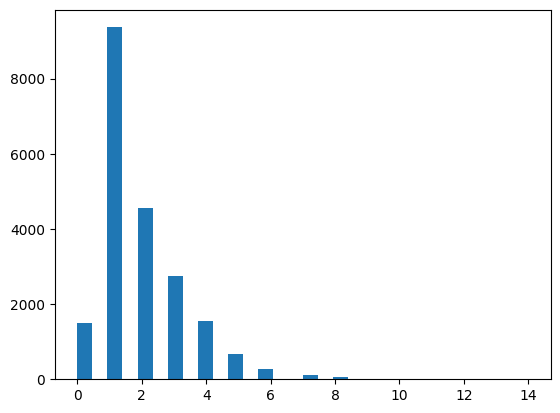

In [211]:
# plot distribution of number of topics per article
import matplotlib.pyplot as plt
import numpy as np

num_topics = [len(article["topics"]) for article in protest_news]
plt.hist(num_topics, bins=30)
plt.show()

In [212]:
from collections import Counter

Counter([str(sorted(a["topics"])) for a in protest_news]).most_common(50)

[("['international']", 2048),
 ("['labour']", 1750),
 ('[]', 1485),
 ("['covid']", 1351),
 ("['right wing']", 582),
 ("['climate']", 567),
 ("['racism']", 556),
 ("['feminism']", 437),
 ("['football']", 390),
 ("['yellow jackets']", 385),
 ("['football', 'labour']", 342),
 ("['anti-immigration']", 301),
 ("['anti capitalism']", 273),
 ("['labour', 'yellow jackets']", 235),
 ("['climate', 'environment']", 184),
 ("['international', 'labour']", 182),
 ("['anti-war']", 147),
 ("['labour', 'right wing']", 140),
 ("['anti-immigration', 'right wing']", 122),
 ("['labour', 'racism']", 121),
 ("['international', 'racism']", 120),
 ("['left wing']", 118),
 ("['international', 'right wing']", 117),
 ("['racism', 'right wing']", 102),
 ("['football', 'international']", 101),
 ("['feminism', 'racism']", 99),
 ("['football', 'right wing']", 99),
 ("['feminism', 'labour']", 93),
 ("['environment']", 91),
 ("['refugees']", 90),
 ("['football', 'racism']", 86),
 ("['left wing', 'right wing']", 84),
 (

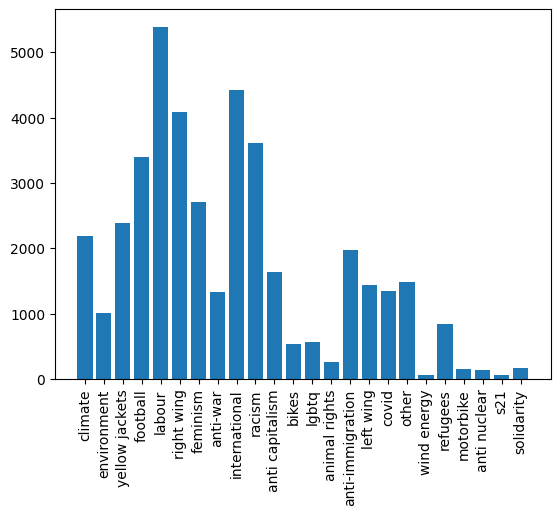

In [213]:
import matplotlib.pyplot as plt
import numpy as np

topics = [a["topics"] for a in protest_news]
topics = [["other"] if len(a) == 0 else a for a in topics]
topics = [item for sublist in topics for item in sublist]
topic_counts = Counter(topics)
plt.bar(topic_counts.keys(), topic_counts.values())
plt.xticks(rotation=90)
plt.show()

In [214]:
no_topic = [a for a in protest_news if len(a["topics"]) == 0]
len(no_topic)

1485

In [215]:
import random

random.seed(20230213)
random.shuffle(no_topic)
for article in no_topic[:3]:
    print(article["text"])

[Airbus-Belegschaft im Konfliktmodus - Gegen Umbaupläne | Onetz]

Ein Mitarbeiter der Airbus-Tochter Premium Aerotec verlässt nach einer Protestaktion mit einem Plakat, auf dem "Wir zeigen dem Management die rote Karte" zu lesen ist, das Betriebsgelände des Unternehmens. Foto: Karl-Josef Hildenbrand/dpa

Bild: Karl-Josef Hildenbrand

Qjcljqj/Mjjcljqj (qlj) - Zcq jclijiic Ajiicqijcljj lcx Mxqljc iäcci qxc qcjicxlci Qcicjcxljiici qcc Dijjicjjljjcqc xi qci Ajiiixcicjqjc cxljiici. Axc iüqxlici „Dcqcxlijjjij jiq Qcqcjji“ xxxlixjcq Miicqiclccicicxic jiq ciciici cxxl jcccxicjc cxi qcq YM Acijii jji cxic ijijxxcqxjc Mjccxijiqcqcciijij cxi.

„Qlx iüqqqc ciciqc Dcqi jijqc“, qiicq xqx Ziccqxcjqcxlqjqxicqjixqlccqcxq Miciqx Yiciq ii Ylqcqcii jql qlcqx Mqcxlqjqjqxqiiicici lc Miijixi- Alcqqclqxxqx. Mixiccqc jxicqqclqxcqc jicxqxcq Mqqljäcclicq iilj ic xqc icxqxqc Zcicxixcqc lc Mxqiqc icx Zcixq qillq jql xqx Dlxjiq-Ailjcqx Mxqilii Dqxicql lc Aixxqcjii, Mixqc icx Diiqjixi.

„Aci xüjjjq ijq Dicljjl jc ci

In [216]:
with open(project_root / "data" / "protest" / "protest_news_predicted.jsonl", "w") as f:
    for article in protest_news:
        f.write(json.dumps(article) + "\n")

In [217]:
# plot timeline of articles per topic
import pandas as pd
from dateutil import parser

common_topics = [k for k, v in topic_counts.most_common(15)]

data = []
for article in protest_news:
    date = parser.parse(article["date"], yearfirst=True, dayfirst=False).date()
    yearquarter = f"{date.year}-{(date.month // 3)*3}"
    yearmonth = f"{date.year}-{str(date.month).zfill(2)}"
    if date.year < 2014:
        continue
    for topic in article["topics"]:
        # if topic not in common_topics:
        #     continue
        data.append({"date": date, "yearmonth": yearmonth, "topic": topic})
df_protest_counts = pd.DataFrame(data)
df_protest_counts.head()

,date,yearmonth,topic
0,2020-10-31,2020-10,climate
1,2020-10-31,2020-10,environment
2,2020-02-22,2020-02,climate
3,2020-02-22,2020-02,yellow jackets
4,2020-02-22,2020-02,football


In [218]:
# aggregate by month
df = df_protest_counts.copy()
df = df.groupby(["yearmonth", "topic"]).size().reset_index(name="count")
df.head()

,yearmonth,topic,count
0,2014-01,animal rights,1
1,2014-01,anti-war,1
2,2014-01,climate,2
3,2014-01,environment,3
4,2014-01,feminism,3


In [219]:
# normalize by month
df["count"] = df["count"] / df.groupby("yearmonth")["count"].transform("sum")
df.head()

,yearmonth,topic,count
0,2014-01,animal rights,0.037037
1,2014-01,anti-war,0.037037
2,2014-01,climate,0.074074
3,2014-01,environment,0.111111
4,2014-01,feminism,0.111111


In [220]:
import altair as alt

# plot timeline of proportion of articles per topic
alt.Chart(df).mark_bar().encode(
    x="yearmonth:T",
    y=alt.Y("count:Q"),
    color="topic:N",
    row="topic:N",
).properties(
    width=800,
    height=50,
)

alt.Chart(...)

In [221]:
df_topic_counts = pd.read_csv(project_root / "data" / "protest" / "topic_counts.csv")
df_topic_counts.head()

,count,date,media_id,name,keyword
0,1,2013-03-13,39267,hna,klima
1,1,2013-03-24,39267,hna,klima
2,1,2013-03-29,39267,hna,klima
3,1,2013-04-04,39267,hna,klima
4,1,2013-04-15,39267,hna,klima


In [222]:
# add column with "topic" (aka movement) (derived from column "keyword")
def find_movement(keyword):
    for movement, keywords in movement_keywords.items():
        if "topic" in keywords and keyword in keywords["topic"]:
            return movement
    return "other"


df_topic_counts["topic"] = df_topic_counts["keyword"].apply(find_movement)
df_topic_counts.head()

,count,date,media_id,name,keyword,topic
0,1,2013-03-13,39267,hna,klima,climate
1,1,2013-03-24,39267,hna,klima,climate
2,1,2013-03-29,39267,hna,klima,climate
3,1,2013-04-04,39267,hna,klima,climate
4,1,2013-04-15,39267,hna,klima,climate


In [223]:
# only keep columns "date", "topic", "count"
df_topic_counts = df_topic_counts[["date", "topic", "count"]]
df_topic_counts["type"] = "general"
df_topic_counts.head()

,date,topic,count,type
0,2013-03-13,climate,1,general
1,2013-03-24,climate,1,general
2,2013-03-29,climate,1,general
3,2013-04-04,climate,1,general
4,2013-04-15,climate,1,general


In [224]:
# aggregate df_protest_counts by date
df_protest_counts = (
    df_protest_counts.groupby(["date", "topic"]).size().reset_index(name="count")
)
df_protest_counts = df_protest_counts[["date", "topic", "count"]]
df_protest_counts["type"] = "protest"
df_protest_counts.head()

,date,topic,count,type
0,2014-01-03,feminism,1,protest
1,2014-01-03,labour,1,protest
2,2014-01-03,racism,1,protest
3,2014-01-03,yellow jackets,1,protest
4,2014-01-04,anti-war,1,protest


In [225]:
# merge df_protest_counts and df_topic_counts
df_protests_and_topics = pd.concat([df_protest_counts, df_topic_counts])
df_protests_and_topics.head()

,date,topic,count,type
0,2014-01-03,feminism,1,protest
1,2014-01-03,labour,1,protest
2,2014-01-03,racism,1,protest
3,2014-01-03,yellow jackets,1,protest
4,2014-01-04,anti-war,1,protest


In [226]:
len(df_protests_and_topics)

1418550

In [227]:
df = df_protests_and_topics.copy()
# aggregate by month
df["date"] = pd.to_datetime(df["date"]).dt.to_period("M")
df["date"] = df["date"].astype(str)
df = df.groupby(["date", "topic", "type"]).sum().reset_index()
df.head()

,date,topic,type,count
0,2010-01,feminism,general,1
1,2010-02,covid,general,1
2,2010-02,feminism,general,1
3,2010-03,anti-war,general,1
4,2010-03,feminism,general,2


In [228]:
len(df)

4025

In [229]:
# start in 2014
df = df[df["date"] >= "2014-01"]

In [230]:
df_norm_topic = df.copy()
# normalize counts by topic
df_norm_topic["count"] = df_norm_topic["count"] / df_norm_topic.groupby(
    ["topic", "type"]
)["count"].transform("max")

In [231]:
import altair as alt

alt.Chart(df_norm_topic).mark_bar(opacity=0.5).encode(
    x="date:T",
    y=alt.Y("count:Q", stack=None),
    color="type:N",
    row="topic:N",
).properties(
    width=800,
    height=50,
)

alt.Chart(...)

In [232]:
df_norm_time = df.copy()
# normalize protest counts and general counts by month
df_norm_time["count"] = df_norm_time["count"] / df_norm_time.groupby(["date", "type"])[
    "count"
].transform("sum")
df.head()

,date,topic,type,count
284,2014-01,animal rights,general,67
285,2014-01,animal rights,protest,1
286,2014-01,anti capitalism,general,39
287,2014-01,anti nuclear,general,27
288,2014-01,anti-immigration,general,331


In [233]:
df_norm_time_norm_topic = df_norm_time.copy()
# normalize counts by topic
df_norm_time_norm_topic["count"] = df_norm_time_norm_topic[
    "count"
] / df_norm_time_norm_topic.groupby(["topic", "type"])["count"].transform("max")

In [234]:
import altair as alt

alt.Chart(df_norm_time_norm_topic).mark_bar(opacity=0.5).encode(
    x="date:T",
    y=alt.Y("count:Q", stack=None),
    color="type:N",
    row="topic:N",
).properties(
    width=800,
    height=50,
)

alt.Chart(...)